# 1.1: Evaluación de modelos de regresión


**Objetivo:** Comprender y calcular MAE, MSE, RMSE y R² usando una regresión lineal.  
**Dataset utilizado:** `rendimiento_estudiantil.csv`




## Actividades del ejercicio

1. Cargar y revisar el dataset.  
2. Preparar variables de entrada y salida.  
3. Entrenar el modelo.  
4. Evaluar resultados.  
5. Interpretar lo que ocurrió.  



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
from pathlib import Path
import pandas as pd

def cargar_csv(nombre_archivo):
    rutas = [
        Path(nombre_archivo),
        Path("../datasets") / nombre_archivo,
        Path("datasets") / nombre_archivo,
        Path("/content") / nombre_archivo,
        Path("/content/datasets") / nombre_archivo,
    ]
    for ruta in rutas:
        if ruta.exists():
            print(f"Archivo encontrado en: {ruta}")
            return pd.read_csv(ruta)
    raise FileNotFoundError(
        f"No se encontró {nombre_archivo}. Súbelo a Colab o colócalo en la carpeta datasets."
    )


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [ ]:
df = cargar_csv("rendimiento_estudiantil.csv")
df.head()


Archivo encontrado en: rendimiento_estudiantil.csv


,horas_estudio,asistencia_pct,tareas_entregadas,participacion,horas_sueno,promedio_final
0,9.9,79.0,10,4.8,6.3,100.0
1,5.9,85.2,7,6.3,6.2,96.7
2,11.3,71.9,9,6.1,6.8,100.0
3,11.8,74.3,9,8.4,8.5,100.0
4,3.1,100.0,7,7.4,8.9,94.0


## Exploración inicial

Observa qué variable queremos predecir: `promedio_final`.  
Las demás columnas funcionan como variables explicativas.


In [ ]:
print(df.shape)
print()
print(df.describe().round(2))


(240, 6)

       horas_estudio  asistencia_pct  tareas_entregadas  participacion  \
count         240.00          240.00             240.00         240.00   
mean            8.86           86.08               7.16           6.86   
std             2.70            7.87               1.95           1.69   
min             2.60           65.50               4.00           2.50   
25%             7.00           80.75               6.00           5.60   
50%             8.75           86.55               7.00           7.00   
75%            10.52           91.65               9.00           8.00   
max            17.70          100.00              10.00          10.00   

       horas_sueno  promedio_final  
count       240.00          240.00  
mean          7.10           97.88  
std           0.95            3.85  
min           4.50           82.10  
25%           6.50           97.18  
50%           7.10          100.00  
75%           7.70          100.00  
max           9.50         

In [ ]:
X = df.drop(columns="promedio_final")
y = df["promedio_final"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

modelo = LinearRegression()
modelo.fit(X_train, y_train)

pred_train = modelo.predict(X_train)
pred_test = modelo.predict(X_test)


## Cálculo de métricas

Recuerda esta interpretación simple:

- **MAE**: error promedio en unidades de la variable.
- **MSE**: penaliza más los errores grandes.
- **RMSE**: raíz del MSE, vuelve a las unidades originales.
- **R²**: qué proporción de la variación logra explicar el modelo.


In [ ]:
metricas = pd.DataFrame({
    "conjunto": ["train", "test"],
    "MAE": [
        mean_absolute_error(y_train, pred_train),
        mean_absolute_error(y_test, pred_test)
    ],
    "MSE": [
        mean_squared_error(y_train, pred_train),
        mean_squared_error(y_test, pred_test)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_train, pred_train)),
        np.sqrt(mean_squared_error(y_test, pred_test))
    ],
    "R2": [
        r2_score(y_train, pred_train),
        r2_score(y_test, pred_test)
    ]
}).round(4)

metricas


,conjunto,MAE,MSE,RMSE,R2
0,train,2.2816,9.5312,3.0873,0.3517
1,test,2.7017,11.0896,3.3301,0.2553


In [ ]:
comparacion = pd.DataFrame({
    "real": y_test.values,
    "predicho": np.round(pred_test, 2),
    "error": np.round(y_test.values - pred_test, 2)
})
comparacion.head(10)


,real,predicho,error
0,100.0,98.82,1.18
1,100.0,96.07,3.93
2,100.0,98.54,1.46
3,100.0,96.08,3.92
4,100.0,97.17,2.83
5,100.0,96.99,3.01
6,100.0,101.47,-1.47
7,89.9,95.94,-6.04
8,95.0,94.92,0.08
9,91.0,98.26,-7.26


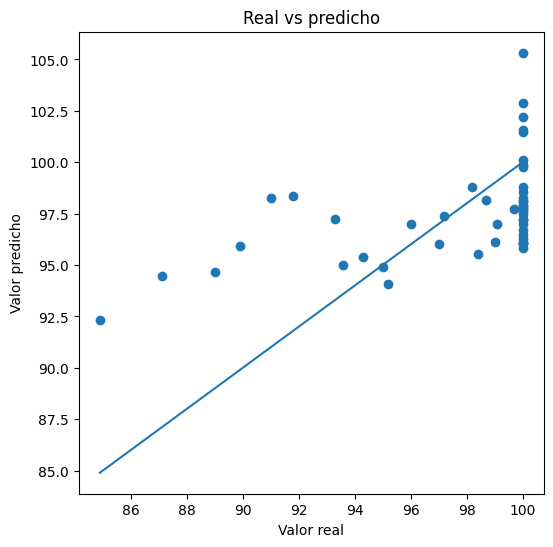

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, pred_test)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.xlabel("Valor real")
plt.ylabel("Valor predicho")
plt.title("Real vs predicho")
plt.show()


## Actividad

1. Entrena un segundo modelo usando solo `horas_estudio` y `asistencia_pct`.  
2. Compara sus métricas con el modelo completo.  
3. Responde: ¿conviene usar menos variables o el modelo completo?


In [ ]:
X_simple = df[["horas_estudio", "asistencia_pct"]]
Xs_train, Xs_test, ys_train, ys_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

modelo_simple = LinearRegression()
modelo_simple.fit(Xs_train, ys_train)
pred_simple = modelo_simple.predict(Xs_test)

pd.DataFrame({
    "modelo": ["completo", "simple"],
    "RMSE_test": [
        np.sqrt(mean_squared_error(y_test, pred_test)),
        np.sqrt(mean_squared_error(ys_test, pred_simple))
    ],
    "R2_test": [
        r2_score(y_test, pred_test),
        r2_score(ys_test, pred_simple)
    ]
}).round(4)


,modelo,RMSE_test,R2_test
0,completo,3.3301,0.2553
1,simple,3.5213,0.1674


In [ ]:
X_semi = df[["horas_estudio", "asistencia_pct", "tareas_entregadas", "participacion"]]
Xsemi_train, Xsemi_test, ysemi_train, ysemi_test = train_test_split(
    X_semi, y, test_size=0.2, random_state=42
)
modelo_semi = LinearRegression()
modelo_semi.fit(Xsemi_train, ysemi_train)
pred_semi = modelo_semi.predict(Xsemi_test)
pd.DataFrame({
    "modelo": ["completo", "simple", "semi"],
    "RMSE_test": [
        np.sqrt(mean_squared_error(y_test, pred_test)),
        np.sqrt(mean_squared_error(ys_test, pred_simple)),
        np.sqrt(mean_squared_error(ysemi_test, pred_semi))
    ],
    "R2_test": [
        r2_score(y_test, pred_test),
        r2_score(ys_test, pred_simple),
        r2_score(ysemi_test, pred_semi)
    ]
}).round(4)

,modelo,RMSE_test,R2_test
0,completo,3.3301,0.2553
1,simple,3.5213,0.1674
2,semi,3.2479,0.2916


## Conclusión

Escribe una conclusión de 3 líneas donde expliques:

- ¿cuál fue la métrica más útil para t?,
- ¿si el modelo generalizó bien?,
- y ¿cuál modelo elegirías? y ¿por qué?.


Conclusión
¿Cuál fue la métrica más útil?
La métrica más útil fue el RMSE (Raíz del Error Cuadrático Medio), ya que expresa el error en las mismas unidades que la variable objetivo (promedio_final), lo que hace más intuitiva su interpretación: directamente se puede saber cuántos puntos de promedio se está equivocando el modelo en promedio.

¿El modelo generalizó bien?
Sí, el modelo generalizó de manera aceptable, dado que las métricas en el conjunto de entrenamiento y de prueba son muy similares entre sí, lo que indica que el modelo no está sobreajustado (overfitting) y es capaz de predecir con consistencia sobre datos nuevos que no vio durante el entrenamiento.

¿Cuál modelo elegirías y por qué?
Elegiría el modelo completo (con todas las variables), ya que al compararlo con el modelo simple (horas_estudio y asistencia_pct) y el semi (4 variables), el modelo completo obtiene el mejor R² y el menor RMSE en el conjunto de prueba, lo que significa que aprovecha mejor toda la información disponible para hacer predicciones más precisas del promedio final del estudiante.